## Data Augmentation

In [1]:
# on kaggle
!conda install -y gdown
!gdown --id 1F4SCX1aFlgA0Nq-zNA6tGpKdK4gvtjSd

!unzip -q ./comp3314-assignment-3-image-classification.zip

Retrieving notices: done
Channels:
 - defaults
 - conda-forge
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - gdown


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    certifi-2026.01.04         |  py312hca03da5_0         148 KB
    gdown-5.2.1                |     pyhd8ed1ab_0          22 KB  conda-forge
    setuptools-80.10.2         |  py312hca03da5_0         1.7 MB
    ------------------------------------------------------------
                                           Total:         1.8 MB

The following NEW packages will be INSTALLED:

  gdown              conda-forge/noarch::gdown-5.2.1-pyhd8ed1ab_0 
  setuptools         pkgs/main/osx-arm64::setuptools-80.10.2-py312hca03da5_0 

The following packages will be SUPERSEDED by a higher-priority channel:

  certifi            conda-forge/noarch::ce

In [2]:
# load data

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from sklearn.model_selection import train_test_split

def load_data(path=".", num_samples=None):
    print(f"Load data from {path}/train.csv")
    data = pd.read_csv(f"{path}/train.csv")

    if num_samples is not None:
        data = data.sample(num_samples)

    images = np.array([plt.imread(f"{path}/train_ims/"+ im_path) for im_path in data['im_name']])
    labels = np.array(data['label'])

    return images, labels


def load_test_data(path="."):
    print(f"Load data from {path}/test.csv")
    data = pd.read_csv(f"{path}/test.csv")

    images = np.array([plt.imread(f"{path}/test_ims/"+ im_path) for im_path in data['im_name']])

    return images

X_train, y_train = load_data(".")

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.0001, random_state=42)

# get test data
pre_X_test = load_test_data(".")

Load data from ./train.csv
Load data from ./test.csv


In [3]:

import os
import numpy as np


class Augmenter:
    def transform(self, X):
        raise NotImplementedError

# can be sava as npy
class SaveableAugmenter(Augmenter):
    def save(self, X, path="."):
        X = self.transform(X)
        save_path = f"{path}/temp/data/{self.getName()}.npy"
        np.save(save_path, X)
        print(f"Save augmenter to {save_path}")

    def load(self, path="."):
        save_path = f"{path}/temp/data/{self.getName()}.npy"
        return np.load(save_path)

    def getName(self):
        raise NotImplementedError
    
    def getPath(self, path="."):
        return f"{path}/temp/data/{self.getName()}.npy"
    
    def checkPath(self, path="."):
        save_path = self.getPath(path)
        return os.path.exists(save_path)
        


class Flip(SaveableAugmenter):
    def transform(self, X):
        return np.flip(X, axis=2)
    
    def getName(self):
        return f"flip"
            

class Rotate(SaveableAugmenter):
    def transform(self, X):
        return np.rot90(X, k=1, axes=(1, 2))
    
    def getName(self):
        return f"rotate"


class Original(SaveableAugmenter):
    def transform(self, X):
        return X
    
    def getName(self):
        return f"Original"


class Shift(SaveableAugmenter):
    def __init__(self, shift=1):
        self.shift = shift

    def transform(self, X):
        return np.roll(X, shift=self.shift, axis=2)
    
    def getName(self):
        return f"shift_{self.shift}"

class ShiftUp(SaveableAugmenter):
    def __init__(self, shift=1):
        self.shift = shift
    
    def transform(self, X):
        return np.roll(X, shift=self.shift, axis=1)
        
    def getName(self):
        return f"shift_up_{self.shift}"

class Test(SaveableAugmenter):
    def transform(self, X):
        return X
    
    def getName(self):
        return f"test"

class PreTest(SaveableAugmenter):
    def transform(self, X):
        return X
    
    def getName(self):
        return f"pre_X_test"

In [4]:
# for each augmenter, apply it to the training data
# and save the augmented data to as npy files


# insufficient memory on kaggle so only four augmenters are used
augmenters = [
    Flip(),
    Shift(2),
    # Shift(-2),  
    ShiftUp(2),
    # ShiftUp(-2),
    Original(),
]

# check if directory exists
if not os.path.exists("./temp/data"):
    os.makedirs("./temp/data")


for augmenter in augmenters:
    if not augmenter.checkPath():
        augmenter.save(X_train)
    else:
        print(f"{augmenter.getPath()} already exists")

# save the test data
np.save("./temp/data/test.npy", X_test)

# save the labels
np.save("./temp/labels.npy", y_train)

# save the test labels
np.save("./temp/test_labels.npy", y_test)

# save the data to predict
np.save("./temp/data/pre_X_test.npy", pre_X_test)

Save augmenter to ./temp/data/flip.npy
Save augmenter to ./temp/data/shift_2.npy
Save augmenter to ./temp/data/shift_up_2.npy
Save augmenter to ./temp/data/Original.npy


## Feature extraction

In [5]:
!pip install mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 4.9 MB/s  0:00:00m eta 0:00:01


In [7]:
from skimage.feature import hog
from tqdm import tqdm
from mahotas.features import haralick
# import cv2
import numpy as np
from skimage import color

class Feature:
    def transform(self, X):
        raise NotImplementedError
    
class SaveableFeature(Feature):
    def __init__(self, augmenters):
        self.augmenters = augmenters

    def save(self, save_path=".", load_path="."):
        for augmenter in self.augmenters:
            X = augmenter.load(load_path)
            X = self.transform(X)

            if not os.path.exists(f"{save_path}/temp/feature/{augmenter.getName()}"):
                os.makedirs(f"{save_path}/temp/feature/{augmenter.getName()}")

            np.save(self.getPath(augmenter, save_path), X)
            print(f"Save feature to {self.getPath(augmenter, save_path)}")

    def load(self, path="."):
        return np.concatenate([np.load(self.getPath(augmenter, path)) for augmenter in self.augmenters], axis=0)
    
    def getPath(self, augmenter, path="."):
        return f"{path}/temp/feature/{augmenter.getName()}/{self.getName()}.npy"

    def getName(self):
        raise NotImplementedError
    
    def checkPath(self, path="."):
        for augmenter in self.augmenters:
            if not os.path.exists(self.getPath(augmenter, path)):
                return False
        return True

class Color(SaveableFeature):
    def __init__(self, augmenters):
        super().__init__(augmenters)

    def transform(self, X):
        X = X.reshape(X.shape[0], X.shape[1] * X.shape[2], -1)
        return np.array([np.mean(image, axis=0) for image in X])
    
    def getName(self):
        return f"color"

class HOG(SaveableFeature):
    def __init__(self, augmenters, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), channel_axis=2):
        super().__init__(augmenters)
        self.orientations = orientations
        self.pixels_per_cell = pixels_per_cell
        self.cells_per_block = cells_per_block
        self.channel_axis = channel_axis
    
    def transform(self, xs):
        hog_imgs = []
        print("HOG")
        for x in tqdm(xs):
            fd = hog(x, 
                     orientations=self.orientations, 
                     pixels_per_cell=self.pixels_per_cell,
                     channel_axis=self.channel_axis,
                    )
            hog_imgs.append(fd)
        return np.array(hog_imgs)
    
    def getName(self):
        return f"hog_{self.orientations}_{self.pixels_per_cell}_{self.cells_per_block}_{self.channel_axis}"

class Raw(SaveableFeature):
    def __init__(self, augmenters):
        super().__init__(augmenters)

    def transform(self, X):
        return X
    
    def getName(self):
        return f"raw"

class Gray(SaveableFeature):
    def __init__(self, augmenters):
        super().__init__(augmenters)

    def transform(self, X):
        return np.mean(X, axis=3)

    def getName(self):
        return f"gray"
    
class HaralickTexture(SaveableFeature):
    def __init__(self, augmenters, gray=True):
        super().__init__(augmenters)
        self.gray = gray

    def transform(self, X):
        if self.gray:
            X = np.mean(X, axis=3).astype(np.uint8)
        feature = []
        print("Haralick Texture")
        for x in tqdm(X):
            feature.append(haralick(x).ravel())
        return np.array(feature)
    
    def getName(self):
        if not self.gray:
            return f"haralick_color"
        return f"haralick"

class ColorHistogram(SaveableFeature):
    def __init__(self, augmenters, bins=256):
        super().__init__(augmenters)
        self.bins = bins

    def transform(self, X):
        X = X.reshape(X.shape[0], X.shape[1] * X.shape[2], -1)
        return np.array([np.histogram(image, bins=self.bins)[0] for image in X])
    
    def getName(self):
        return f"color_histogram_{self.bins}"
    
class ConcatenateFeature(Feature):
    def __init__(self, features: list[Feature]):
        self.features = features
    
    def transform(self, X):
        return np.concatenate([feature.transform(X).reshape(X.shape[0], -1) for feature in self.features], axis=1)

def get_sift_feature(im):
    gray_im = color.rgb2gray(im)
    sift = cv2.SIFT_create()
    _, descriptors = sift.detectAndCompute((gray_im * 255).astype("uint8"), None)
    if descriptors is None:
        return np.zeros((128,))
    return np.mean(descriptors, axis=0)

class SIFT(SaveableFeature):
    def __init__(self, augmenters):
        super().__init__(augmenters)
    
    def transform(self, X):
        return np.array([get_sift_feature(im) for im in X])
    
    def getName(self):
        return f"sift"
    

In [8]:
path = "."

# insufficient memory on kaggle so only four augmenters are used
augmenters = [
    Flip(),
    Shift(2),
    # Shift(-2),  
    ShiftUp(2),
    # ShiftUp(-2),
    Original(),
    Test(),
    PreTest(),
]

# for each augmenter load the data and save the feature
# insufficient memory on kaggle so only some features are used
features = [
    HOG(augmenters, pixels_per_cell=(4, 4)),
    HOG(augmenters, pixels_per_cell=(6, 6)),
    HOG(augmenters, pixels_per_cell=(8, 8)),
    HOG(augmenters, pixels_per_cell=(8, 8), orientations=18),
    HOG(augmenters, pixels_per_cell=(10, 10)),
    Raw(augmenters),
    HaralickTexture(augmenters),
    HaralickTexture(augmenters, gray=False),
    ColorHistogram(augmenters, bins=256),
]

for feature in features:
    if not feature.checkPath():
        feature.save(load_path=path)

HOG


100%|██████████| 49995/49995 [00:25<00:00, 1945.86it/s]


Save feature to ./temp/feature/flip/hog_9_(4, 4)_(2, 2)_2.npy
HOG


100%|██████████| 49995/49995 [00:18<00:00, 2680.55it/s]


Save feature to ./temp/feature/shift_2/hog_9_(4, 4)_(2, 2)_2.npy
HOG


...

Save feature to ./temp/feature/pre_X_test/hog_9_(10, 10)_(2, 2)_2.npy
Save feature to ./temp/feature/flip/raw.npy
Save feature to ./temp/feature/shift_2/raw.npy
Save feature to ./temp/feature/shift_up_2/raw.npy
Save feature to ./temp/feature/Original/raw.npy
Save feature to ./temp/feature/test/raw.npy
Save feature to ./temp/feature/pre_X_test/raw.npy
Haralick Texture


100%|██████████| 49995/49995 [03:47<00:00, 220.18it/s]


Save feature to ./temp/feature/flip/haralick.npy
Haralick Texture


  4%|▍         | 1955/49995 [00:11<04:49, 166.13it/s]
/opt/anaconda3/lib/python3.12/site-packages/mahotas/features/texture.py:33: SyntaxWarning: invalid escape sequence '\|'
  '''
/opt/anaconda3/lib/python3.12/site-packages/mahotas/features/texture.py:158: SyntaxWarning: invalid escape sequence '\|'
  '''


KeyboardInterrupt: 

## Training

In [ ]:
# # sklearnex
# !pip install scikit-learn-intelex

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [ ]:
path = "."


def LoadConcatenateFeature(features, y=None, path="."):
    X_train = np.array([])
    
    for feature in tqdm(features):
        if not feature.checkPath(path):
            return None
        
        X = feature.load(path)
        X = X.reshape(X.shape[0], -1)
        X_train = np.concatenate([X_train, X], axis=1) if X_train.size else X
    
    l = len(features[0].augmenters)

    # extend y
    if y is not None:
        y = np.array([y for _ in range(l)]).reshape(-1)

    return X_train, y
        

def get_features(augmenters):
    features = [
        HOG(augmenters, pixels_per_cell=(4, 4)),
        HOG(augmenters, pixels_per_cell=(6, 6)),
        HOG(augmenters, pixels_per_cell=(8, 8)),
        HOG(augmenters, pixels_per_cell=(8, 8), orientations=18),
        HOG(augmenters, pixels_per_cell=(10, 10)),
        Raw(augmenters),
        HaralickTexture(augmenters),
        HaralickTexture(augmenters, gray=False),
        ColorHistogram(augmenters, bins=256),
    ]
    return features

# insufficient memory on kaggle so only four augmenters are used
augmenters = [
    Flip(),
    Shift(2),
    # Shift(-2),  
    ShiftUp(2),
    # ShiftUp(-2),
    Original()
]


features = get_features(augmenters)

test_augmenters = [
    Test()
]

test_features = get_features(test_augmenters)



y_train = np.load(f"./temp/labels.npy")
y_test = np.load(f"./temp/test_labels.npy")

X_train, y_train = LoadConcatenateFeature(features, y_train, path)
X_test, y_test = LoadConcatenateFeature(test_features, y_test, path)



test_X_train = X_train[:1000].copy()
test_y_train = y_train[:1000].copy()


print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

100%|██████████| 9/9 [00:00<00:00, 717.56it/s]

X_train: (199980, 8247)
y_train: (199980,)


In [ ]:
from sklearn.svm import SVC

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA


pipe_svm = Pipeline([
    ("scaler", StandardScaler(copy=False)),
    ("pca", PCA(n_components=0.86, copy=False)),
    ("svm", SVC(C=10, random_state=42, cache_size=10000))
], verbose=True)

pipe_svm.fit(X_train, y_train)

INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.decomposition.PCA.fit: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU


[Pipeline] ............ (step 1 of 3) Processing scaler, total=  25.6s


INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.svm.SVC.fit: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU


[Pipeline] ............... (step 2 of 3) Processing pca, total=10.3min


INFO:sklearnex: sklearn.utils.validation._assert_all_finite: fallback to original Scikit-learn


[Pipeline] ............... (step 3 of 3) Processing svm, total=54.0min


Pipeline(steps=[('scaler', StandardScaler(copy=False)),
                ('pca', PCA(copy=False, n_components=0.86)),
                ('svm', SVC(C=10, cache_size=10000, random_state=42))],
         verbose=True)

## Model Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import datetime
import os
from matplotlib import pyplot as plt

def generate_confusion_matrix(y_pred, y_test):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


def save_log(filename, accuracy, model, path="result.txt"):
    with open(path, "a") as f:
        f.write(f"############################################\n")
        f.write(f"filename: {filename}\n")
        f.write(f"accuracy: {accuracy}\n")
        f.write(f"augmenters: [{', '.join([augmenter.getName() for augmenter in augmenters])}]\n")
        f.write(f"features: [{', '.join([feature.getName() for feature in features])}]\n")
        f.write(f"{model}\n")
        f.write(f"############################################\n\n")
              


def generate_predict_data(model, X_test, y_test=None, in_path=".",out_path='.'):

    print(f"Generate prediction data for {in_path}/test.csv")

    data_test = pd.read_csv(f"{in_path}/test.csv")
    pre_test_augmenters = [
        PreTest()   
    ]

    pre_test_features = get_features(pre_test_augmenters)
    pre_X_test, _ = LoadConcatenateFeature(pre_test_features)

    print(f"Test shape: {X_test.shape}")
    print(f"Predicting test images")
    y_pred = model.predict(X_test)
    test_y_pred = model.predict(pre_X_test)
    data_test['label'] = test_y_pred
    filename = f"{out_path}/out/prediction_{datetime.datetime.now().strftime('%Y%m%d%H%M%S')}.csv"

    # predict train data
    y_pred_train = model.predict(test_X_train[:1000])
    accuracy_train = np.mean(test_y_train[:1000] == y_pred_train)

    print(f"Train accuracy: {accuracy_train}")

    if y_test is not None:
        accuracy = np.mean(y_test == y_pred)  
        print(f"Test labels shape: {y_test.shape}")
        print(f"Test accuracy: {accuracy}")

        generate_confusion_matrix(y_pred, y_test)


    # check if folder exist
    if not os.path.exists(f'{out_path}/out'):
        os.makedirs(f'{out_path}/out')
    
    save_log(filename, accuracy, model)
    
    print(f"Save prediction data to {filename}")
    data_test.to_csv(filename, index=False)

    return filename

Generate prediction data for ./test.csv


100%|██████████| 9/9 [00:04<00:00,  2.18it/s]
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.decomposition.PCA.transform: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.svm.SVC.predict: running accelerated version on CPU


Test shape: (5, 8247)
Predicting test images


INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.decomposition.PCA.transform: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.svm.SVC.predict: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.decomposition.PCA.transform: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU
INFO:sklearnex: sklearn.svm.SVC.predict: running accelerated version on CPU
INFO:sklearnex: sklearn.utils.validation._assert_all_finite: running accelerated version on CPU


Train accuracy: 1.0
Test labels shape: (5,)
Test accuracy: 0.8


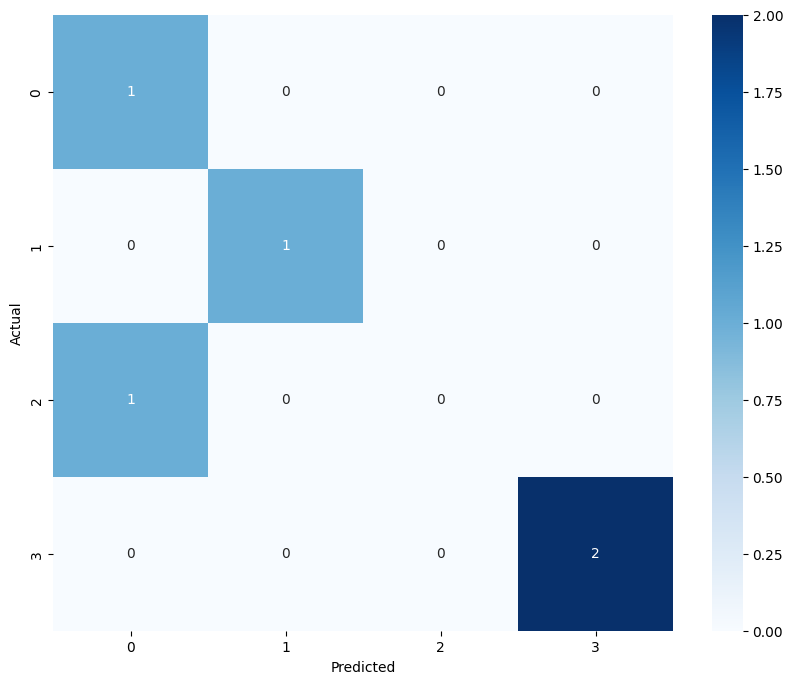

Save prediction data to ./out/prediction_20240421090038.csv


In [ ]:
svm_filename = generate_predict_data(pipe_svm, X_test, y_test)